# Domain Assumption Pipeline

이 노트북은 **CLIP 모델**을 활용하여 입력 이미지의 **도메인(스타일)을 자동으로 추정**하는 파이프라인을 구현합니다.

> **도메인이란?** 이미지가 어떤 스타일로 표현되었는지를 의미합니다.  
> 예: 실사 사진(photo), 스케치(sketch), 만화(cartoon) 등

### 전체 흐름 한눈에 보기

```
[입력 이미지]
     ↓
1. 도메인 프롬프트 임베딩  →  각 도메인을 텍스트로 표현한 벡터 생성
     ↓
2. MTA (MeanShift 기반 증강)  →  이미지를 여러 각도로 변형 후, 노이즈 제거해 핵심 벡터 추출
     ↓
3. 코사인 유사도 계산  →  이미지 벡터 vs 도메인 텍스트 벡터 비교
     ↓
4. Softmax로 가중치 변환  →  "sketch일 확률 60%, photo일 확률 20%, ..." 형태로 변환
     ↓
5. 결과 시각화  →  바 차트로 도메인 추정 결과 출력
```

필요한 모듈 설치 및 import

CLIP은 OpenAI가 공개한 멀티모달 모델로, 이미지와 텍스트를 동일한 벡터 공간에 표현합니다.  
아래 셀에서 CLIP 패키지와 기타 필요한 라이브러리를 설치하고 불러옵니다.

- `torch` / `torchvision`: 딥러닝 연산 및 이미지 전처리
- `clip`: CLIP 모델 로드 및 추론
- `PIL`: 이미지 파일 읽기
- `matplotlib` / `numpy`: 결과 시각화 및 수치 연산

In [1]:
!pip install ftfy regex tqdm git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-szjt1jpv
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-szjt1jpv
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [2]:
import torch
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch import nn
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
import torch.utils.data

from PIL import Image
from types import SimpleNamespace
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import clip

CLIP 모델 로드

`ViT-B/32`는 CLIP에서 이미지 인코더로 사용하는 Vision Transformer 모델입니다.  
GPU가 있으면 자동으로 GPU를 사용하고, 없으면 CPU로 실행됩니다.

> **ViT(Vision Transformer)란?** 이미지를 작은 패치(조각)로 나눠 Transformer 구조로 처리하는 이미지 인코더입니다.  
> `ViT-B/32`는 이미지를 32×32 픽셀 단위로 나누는 Base 크기 모델을 의미합니다.

`model.eval()`은 모델을 추론 모드로 전환합니다 (학습 중에 사용하는 Dropout 등을 비활성화).

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

도메인 프롬프트 정의

각 도메인(스타일)을 대표하는 **자연어 문장(프롬프트) 목록**을 정의합니다.

하나의 도메인을 여러 표현으로 나타내면, 더 다양한 경우를 커버할 수 있습니다.  
예를 들어 스케치 도메인은 아래처럼 다양하게 표현됩니다:
- `"a black and white sketch"`
- `"a line drawing"`
- `"a contour drawing"`
- ...

이 문장들의 임베딩을 평균 내어 해당 도메인의 **대표 벡터**를 만듭니다.

| 도메인 | 설명 |
|--------|------|
| `photo` | 실사 사진 |
| `sketch` | 선화/스케치 |
| `cartoon` | 만화/애니메이션 스타일 |
| `rendering` | 3D 컴퓨터 렌더링 |
| `painting` | 회화 스타일 |
| `sculpture` | 조각 작품 |
| `origami` | 종이 접기 |
| `tattoo` | 타투 스타일 |
| `graffiti` | 그라피티/거리 예술 |
| 그 외... | deviantart, embroidery, graphic, sticker, toy, videogame 등 |

In [4]:
domain_prompts = {
    "photo": [
        "a real photo",
        "a natural photograph",
        "a realistic photographic image",
        "a color photograph",
        "a close-up photo",
    ],
    "cartoon": [
        "a cartoon image",
        "a colorful cartoon illustration",
        "an animated cartoon image",
        "a comic style illustration",
        "a simple cartoon drawing",
        "a brightly colored cartoon image",
        "a vivid colorful animated illustration",
        "a saturated cartoon drawing",
    ],
    "deviantart": [
        "a deviantart digital artwork",
        "a digital art illustration",
        "a highly stylized digital artwork",
    ],
    "embroidery": [
        "an embroidered artwork",
        "a stitched embroidery design",
        "an image sewn with thread",
    ],
    "graffiti": [
        "a graffiti artwork on a wall",
        "a spray-painted graffiti image",
        "street art graffiti",
    ],
    "graphic": [
        "a vector graphic design",
        "a flat graphic illustration",
        "a clean digital graphic image",
    ],
    "misc": [
        "a miscellaneous stylized image",
        "a mixed style artwork",
        "an unusual artistic image",
    ],
    "origami": [
        "an origami paper figure",
        "a folded paper object",
        "a paper craft origami image",
    ],
    "sculpture": [
        "a three-dimensional sculpture",
        "a sculpted object",
        "a carved statue artwork",
    ],
    "sketch": [
        "a black and white sketch",
        "a grayscale sketch",
        "a line drawing",
        "a contour drawing",
        "an outline drawing",
        "a monochrome line drawing",
        "a black and white line art image",
        "a clean black outline drawing",
        "a sparse black line drawing on white background",
        "a sketch with only object contours",
        "a white background with thin black outlines",
        "a monochrome contour sketch",
        "a simple object outline drawing",
        "a line-art sketch with no shading",
        "a black ink outline drawing",
        "a sketch made only of edges and contours",
        "a minimal contour-only drawing",
        "a line art illustration",
        "a black and white line art drawing",
        "a minimal line-art image",
    ],
    "sticker": [
        "a sticker illustration",
        "a colorful sticker image",
        "a cutout sticker graphic",
    ],
    "tattoo": [
        "a tattoo design",
        "a black ink tattoo drawing",
        "a tattoo style illustration",
    ],
    "toy": [
        "a plastic toy figure",
        "a plush toy",
        "a small toy model",
    ],
    "videogame": [
        "a video game rendering",
        "a 3d game character render",
        "a computer game screenshot style image",
    ],
    "drawing": [
        "a hand-drawn drawing",
        "a simple doodle drawing",
        "a colored pencil drawing",
    ],
    "rendering": [
        "a 3d rendered image",
        "a computer generated rendering",
        "a realistic digital rendering",
    ],
    "plastic": [
        "a plastic figure",
        "a shiny plastic object",
        "a molded plastic toy",
    ],
}

1. 도메인 프롬프트 임베딩

앞서 정의한 도메인별 프롬프트 문장들을 **CLIP 텍스트 인코더**에 통과시켜 벡터로 변환합니다.

1. 각 도메인의 프롬프트 문장들을 CLIP이 이해할 수 있는 토큰(숫자)으로 변환
2. CLIP 텍스트 인코더로 각 문장의 임베딩(벡터) 추출
3. 여러 문장의 임베딩을 **평균**내어 도메인 대표 벡터 생성
4. 정규화(norm=1)하여 코사인 유사도 계산에 적합한 형태로 변환

결과물 `domain_features`: 각 도메인의 대표 텍스트 벡터들을 쌓은 행렬 → 이후 이미지 벡터와 비교하는 기준점이 됩니다.

In [5]:
domain_features_dict = {}
for domain, prompts in domain_prompts.items():
    tokens = clip.tokenize(prompts).to(device)
    with torch.no_grad():
        embeds = model.encode_text(tokens)
        embeds = embeds / embeds.norm(dim=1, keepdim=True)
    domain_features_dict[domain] = embeds.mean(dim=0)

domain_features = torch.stack(list(domain_features_dict.values()))
domain_names = list(domain_features_dict.keys())

2. MTA (MeanShift Test-time Augmentation) → robust mode 획득

단일 이미지 한 장만으로는 분류 성능이 불안정할 수 있습니다.  
MTA는 이미지를 다양하게 변형(증강)한 뒤, **노이즈가 많은 뷰를 걸러내고** 핵심적인 이미지 표현을 추출합니다.

**구성 함수:**

`make_views(image, n_views)`
- 원본 이미지 1장 + 랜덤 크롭(RandomResizedCrop)으로 생성한 n_views장 = 총 **n_views+1장**의 증강 이미지 생성
- CLIP의 입력 규격에 맞게 크기 조정 및 정규화 적용

`gaussian_kernel(mu, bandwidth, datapoints)`
- 각 이미지 뷰가 전체 분포의 중심(mode)과 얼마나 가까운지 계산
- 중심에 가까울수록 높은 점수 → **핵심 뷰**로 판단
- 멀수록 낮은 점수 → **outlier(잡음 뷰)**로 판단

`solve_mta(model, inputs, args)`
MeanShift 알고리즘으로 **robust mode m\*** 를 반복적으로 계산합니다:

```
1. 모든 증강 뷰를 CLIP 이미지 인코더로 임베딩 추출
2. KNN 기반으로 각 뷰의 밀도(bandwidth) 계산
3. Inlierness 업데이트: 중심에 가까운 뷰에 높은 가중치(y) 부여
4. Mode 업데이트: 높은 가중치를 받은 뷰들의 가중평균으로 mode 갱신
5. 3~4를 수렴할 때까지 반복
```

> 최종 `mode m*`는 outlier 뷰의 영향이 제거된, 이미지의 **본질적인 특징 벡터**입니다.

**주요 파라미터:**
- `lambda_y (0.2)`: inlierness 업데이트 강도 조절
- `lambda_q (4)`: 뷰 간 관계(affinity) 반영 정도
- `bandwidth`: 뷰들의 분산에 따라 자동 계산되는 커널 너비

In [6]:
def make_views(image, n_views):
    """원본 이미지 1장 + RandomResizedCrop n_views장 생성"""
    normalize = transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
    base_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize,
    ])
    crop_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.ToTensor(),
        normalize,
    ])

    original = base_transform(image).unsqueeze(0)
    crops = torch.stack([crop_transform(image) for _ in range(n_views)])
    all_views = torch.cat([original, crops], dim=0)
    return all_views


def gaussian_kernel(mu, bandwidth, datapoints):
    """가우시안 커널 밀도 추정"""
    dist = torch.norm(datapoints - mu, dim=-1, p=2)
    density = torch.exp(-dist**2 / (2 * bandwidth**2))
    return density


def solve_mta(model, inputs, args):
    """MTA: inlierness score 계산 및 robust mode m* 획득"""
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            image_features = model.encode_image(inputs)

    image_features = image_features.float()
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    lambda_y = args.lambda_y
    lambda_q = args.lambda_q
    max_iter = 5
    temperature = 1

    batch_size = image_features.shape[0]

    # Bandwidth 계산 (KNN 기반)
    dist = torch.cdist(image_features, image_features)
    sorted_dist, _ = torch.sort(dist, dim=1)
    k = max(1, int(0.3 * (image_features.shape[0] - 1)))
    selected_distances = sorted_dist[:, 1:k+1] ** 2
    mean_distance = torch.mean(selected_distances, dim=1)
    bandwidth = torch.sqrt(0.5 * mean_distance)

    affinity_matrix = (image_features @ image_features.t() / temperature).softmax(1)

    # 초기화
    y = torch.ones(batch_size, device=image_features.device) / batch_size
    mode = image_features[0]

    convergence = False
    th = 1e-6
    iter_count = 0

    while not convergence:
        density = gaussian_kernel(mode, bandwidth, image_features)

        # Inlierness step
        conv_inlierness = False
        i = 0
        while not conv_inlierness:
            i += 1
            old_y = y
            weighted_affinity = affinity_matrix * y.unsqueeze(0)
            y = F.softmax(1 / lambda_y * (density + lambda_q * torch.sum(weighted_affinity, dim=1)), dim=-1)
            if torch.norm(old_y - y) < th or i >= max_iter:
                conv_inlierness = True

        # Mode step
        conv_mode = False
        i = 0
        while not conv_mode:
            i += 1
            old_mode = mode
            density = gaussian_kernel(mode, bandwidth, image_features)
            weighted_density = density * y
            mode = torch.sum(weighted_density.unsqueeze(1) * image_features, dim=0) / torch.sum(weighted_density)
            mode /= mode.norm(p=2, dim=-1)
            if torch.norm(old_mode - mode) < th or i >= max_iter:
                conv_mode = True

        iter_count += 1
        if iter_count >= max_iter:
            convergence = True

    return mode

3. 전체 추정 함수

앞서 정의한 모든 단계를 하나로 묶은 **메인 함수** `estimate_domain()`입니다.

**입력 파라미터:**
| 파라미터 | 기본값 | 설명 |
|----------|--------|------|
| `image_path` | - | 추정할 이미지 파일 경로 |
| `n_views` | 127 | 랜덤 크롭 증강 수 (원본 포함 총 128장) |
| `top_k` | 5 | 결과 시각화 시 상위 몇 개 도메인을 보여줄지 |
| `show_plot` | True | 바 차트 시각화 여부 |

**내부 처리 순서:**
1. 이미지 로드 → RGB 변환
2. `make_views()`로 128개 증강 뷰 생성
3. `solve_mta()`로 robust mode m* 획득
4. `mode @ domain_features.T`로 코사인 유사도 계산
5. `logit_scale` 적용 후 Softmax → 도메인 가중치 산출
6. 결과를 콘솔 출력 + 바 차트로 시각화

**실행 방법 (다음 셀):**
아래 셀을 실행하면 파일 업로드 창이 나타납니다. 분류하고 싶은 이미지를 업로드하면 자동으로 도메인 추정 결과가 출력됩니다.

> **예상 출력 형태:**
> ```
> 이미지 로드 완료: my_image.jpg  |  크기: (512, 512)
> 총 128개 뷰 생성 완료
> MTA 완료 → robust mode 획득
> ========================================
> 도메인              가중치
> ----------------------------------------
> sketch           0.6023 ◀ 예측
> photo            0.1842
> cartoon          0.0891
> ...
> ========================================
> 최종 예측 도메인: [SKETCH]
> ```

In [7]:
def estimate_domain(image_path, n_views=127, top_k=5, show_plot=True):
    """
    이미지 경로를 받아 도메인 추정 결과를 반환합니다.

    Args:
        image_path (str): 이미지 파일 경로
        n_views (int): RandomResizedCrop 증강 수 (원본 1장 포함 총 n_views+1장)
        top_k (int): 상위 몇 개 도메인을 출력할지
        show_plot (bool): 결과 바 차트 시각화 여부

    Returns:
        dict: {도메인명: 가중치} 딕셔너리
    """
    # 이미지 로드
    image = Image.open(image_path).convert("RGB")
    print(f"이미지 로드 완료: {image_path}  |  크기: {image.size}")

    # Augmented views 생성
    inputs = make_views(image, n_views).to(device)
    print(f"총 {inputs.shape[0]}개 뷰 생성 완료")

    # MTA → robust mode 획득
    args = SimpleNamespace(lambda_y=0.2, lambda_q=4)
    mode = solve_mta(model, inputs, args)
    print("MTA 완료 → robust mode 획득")

    # 도메인 가중치 계산
    df = domain_features.float()
    df = df / df.norm(dim=1, keepdim=True)
    logit_scale = model.logit_scale.exp()
    similarity = mode @ df.t() * logit_scale
    domain_weights = similarity.softmax(dim=-1)

    # 결과 정리
    result = {name: weight.item() for name, weight in zip(domain_names, domain_weights)}
    sorted_result = dict(sorted(result.items(), key=lambda x: x[1], reverse=True))

    # 콘솔 출력
    print("\n" + "="*40)
    print(f"{'도메인':<15} {'가중치':>8}")
    print("-"*40)
    for i, (name, weight) in enumerate(sorted_result.items()):
        marker = " ◀ 예측" if i == 0 else ""
        print(f"{name:<15} {weight:>8.4f}{marker}")
    print("="*40)
    print(f"\n최종 예측 도메인: [{list(sorted_result.keys())[0].upper()}]")

    # 시각화
    if show_plot:
        top_items = list(sorted_result.items())[:top_k]
        labels = [k for k, v in top_items]
        values = [v for k, v in top_items]

        colors = ["#E74C3C" if i == 0 else "#5DADE2" for i in range(len(labels))]

        fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                                 gridspec_kw={"width_ratios": [1, 2]})

        # 왼쪽: 원본 이미지
        axes[0].imshow(image)
        axes[0].axis("off")

        # 오른쪽: 도메인 가중치 바 차트
        bars = axes[1].barh(labels[::-1], values[::-1], color=colors[::-1], edgecolor="white")
        axes[1].set_xlabel("Domain Weight (Softmax)", fontsize=10)
        axes[1].set_xlim(0, max(values) * 1.3)

        for bar, val in zip(bars, values[::-1]):
            axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                        f"{val:.4f}", va="center", fontsize=9)

        pred_patch = mpatches.Patch(color="#E74C3C", label=f"{labels[0]}")
        axes[1].legend(handles=[pred_patch], loc="lower right", fontsize=9)

        plt.tight_layout()
        plt.show()

    return sorted_result

Saving 렌더링.jpg to 렌더링 (1).jpg
이미지 로드 완료: 렌더링 (1).jpg  |  크기: (279, 161)
총 128개 뷰 생성 완료


/tmp/ipykernel_6215/2232089134.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


MTA 완료 → robust mode 획득

도메인                  가중치
----------------------------------------
rendering         0.8181 ◀ 예측
graphic           0.0603
videogame         0.0283
toy               0.0248
plastic           0.0160
photo             0.0137
misc              0.0127
sketch            0.0120
deviantart        0.0046
sculpture         0.0034
cartoon           0.0021
origami           0.0017
drawing           0.0012
sticker           0.0010
graffiti          0.0001
embroidery        0.0000
tattoo            0.0000

최종 예측 도메인: [RENDERING]


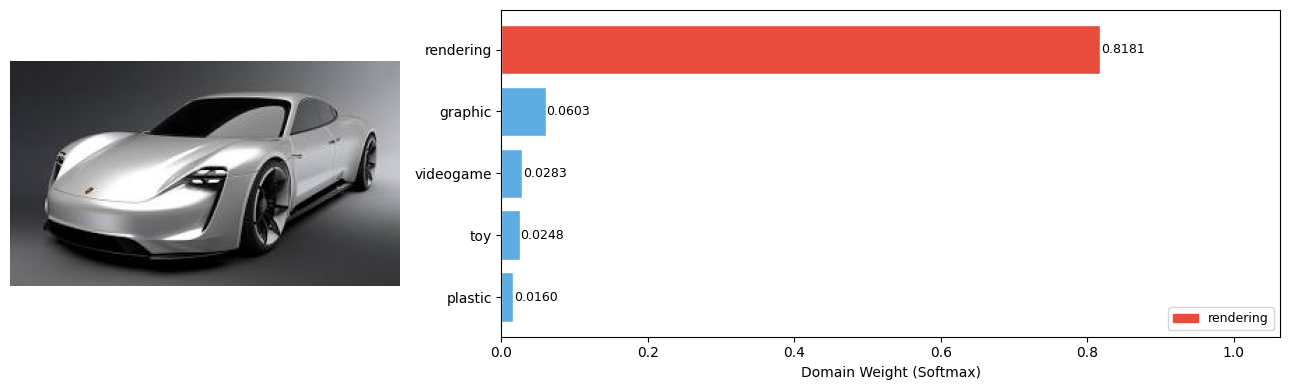

In [8]:
from google.colab import files

uploaded = files.upload()  # 업로드 창이 뜸
IMAGE_PATH = list(uploaded.keys())[0]  # 업로드한 파일명 자동으로 가져오기

result = estimate_domain(
    image_path=IMAGE_PATH,
    n_views=127,
    top_k=5,
    show_plot=True
)